In [25]:
from networkx.algorithms.bipartite.basic import color
from sympy.parsing.sympy_parser import null

words=open('names.txt','r').read().splitlines()

In [28]:
words[:10]

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [29]:
len(words)

32033

In [30]:
min(len(w)for w in words)

2

In [31]:
max(len(w) for w in words)

15

In [47]:
b={}
for w in words:
    chs=['<S>']+list(w)+['<E>']
    for ch1,ch2 in zip(chs, chs[1:]):
        bigram=(ch1,ch2)
        b[bigram]=b.get(bigram,0)+1

In [52]:
#出现的次数b
sorted(b.items(),key=lambda kv:-kv[1])

[(('n', '<E>'), 6763),
 (('a', '<E>'), 6640),
 (('a', 'n'), 5438),
 (('<S>', 'a'), 4410),
 (('e', '<E>'), 3983),
 (('a', 'r'), 3264),
 (('e', 'l'), 3248),
 (('r', 'i'), 3033),
 (('n', 'a'), 2977),
 (('<S>', 'k'), 2963),
 (('l', 'e'), 2921),
 (('e', 'n'), 2675),
 (('l', 'a'), 2623),
 (('m', 'a'), 2590),
 (('<S>', 'm'), 2538),
 (('a', 'l'), 2528),
 (('i', '<E>'), 2489),
 (('l', 'i'), 2480),
 (('i', 'a'), 2445),
 (('<S>', 'j'), 2422),
 (('o', 'n'), 2411),
 (('h', '<E>'), 2409),
 (('r', 'a'), 2356),
 (('a', 'h'), 2332),
 (('h', 'a'), 2244),
 (('y', 'a'), 2143),
 (('i', 'n'), 2126),
 (('<S>', 's'), 2055),
 (('a', 'y'), 2050),
 (('y', '<E>'), 2007),
 (('e', 'r'), 1958),
 (('n', 'n'), 1906),
 (('y', 'n'), 1826),
 (('k', 'a'), 1731),
 (('n', 'i'), 1725),
 (('r', 'e'), 1697),
 (('<S>', 'd'), 1690),
 (('i', 'e'), 1653),
 (('a', 'i'), 1650),
 (('<S>', 'r'), 1639),
 (('a', 'm'), 1634),
 (('l', 'y'), 1588),
 (('<S>', 'l'), 1572),
 (('<S>', 'c'), 1542),
 (('<S>', 'e'), 1531),
 (('j', 'a'), 1473),
 (

In [50]:
b.items()


dict_items([(('<S>', 'e'), 1531), (('e', 'm'), 769), (('m', 'm'), 168), (('m', 'a'), 2590), (('a', '<E>'), 6640), (('<S>', 'o'), 394), (('o', 'l'), 619), (('l', 'i'), 2480), (('i', 'v'), 269), (('v', 'i'), 911), (('i', 'a'), 2445), (('<S>', 'a'), 4410), (('a', 'v'), 834), (('v', 'a'), 642), (('<S>', 'i'), 591), (('i', 's'), 1316), (('s', 'a'), 1201), (('a', 'b'), 541), (('b', 'e'), 655), (('e', 'l'), 3248), (('l', 'l'), 1345), (('l', 'a'), 2623), (('<S>', 's'), 2055), (('s', 'o'), 531), (('o', 'p'), 95), (('p', 'h'), 204), (('h', 'i'), 729), (('<S>', 'c'), 1542), (('c', 'h'), 664), (('h', 'a'), 2244), (('a', 'r'), 3264), (('r', 'l'), 413), (('l', 'o'), 692), (('o', 't'), 118), (('t', 't'), 374), (('t', 'e'), 716), (('e', '<E>'), 3983), (('<S>', 'm'), 2538), (('m', 'i'), 1256), (('a', 'm'), 1634), (('m', 'e'), 818), (('<S>', 'h'), 874), (('r', 'p'), 14), (('p', 'e'), 197), (('e', 'r'), 1958), (('r', '<E>'), 1377), (('e', 'v'), 463), (('v', 'e'), 568), (('l', 'y'), 1588), (('y', 'n'), 18

In [37]:
list(w)

['e', 'm', 'm', 'a']

In [34]:
w

'emma'

In [35]:
w[1:]

'mma'

In [53]:
import  torch

In [70]:
N=torch.zeros((27,27),dtype=torch.int32)

In [75]:
chars=sorted(list(set(''.join(words))))
stoi={s:i+1 for i,s in enumerate(chars)}
stoi['.']=0
itos={i:s for s,i in stoi.items()}

In [76]:
for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        N[ix1,ix2]+=1

(np.float64(-0.5), np.float64(26.5), np.float64(26.5), np.float64(-0.5))

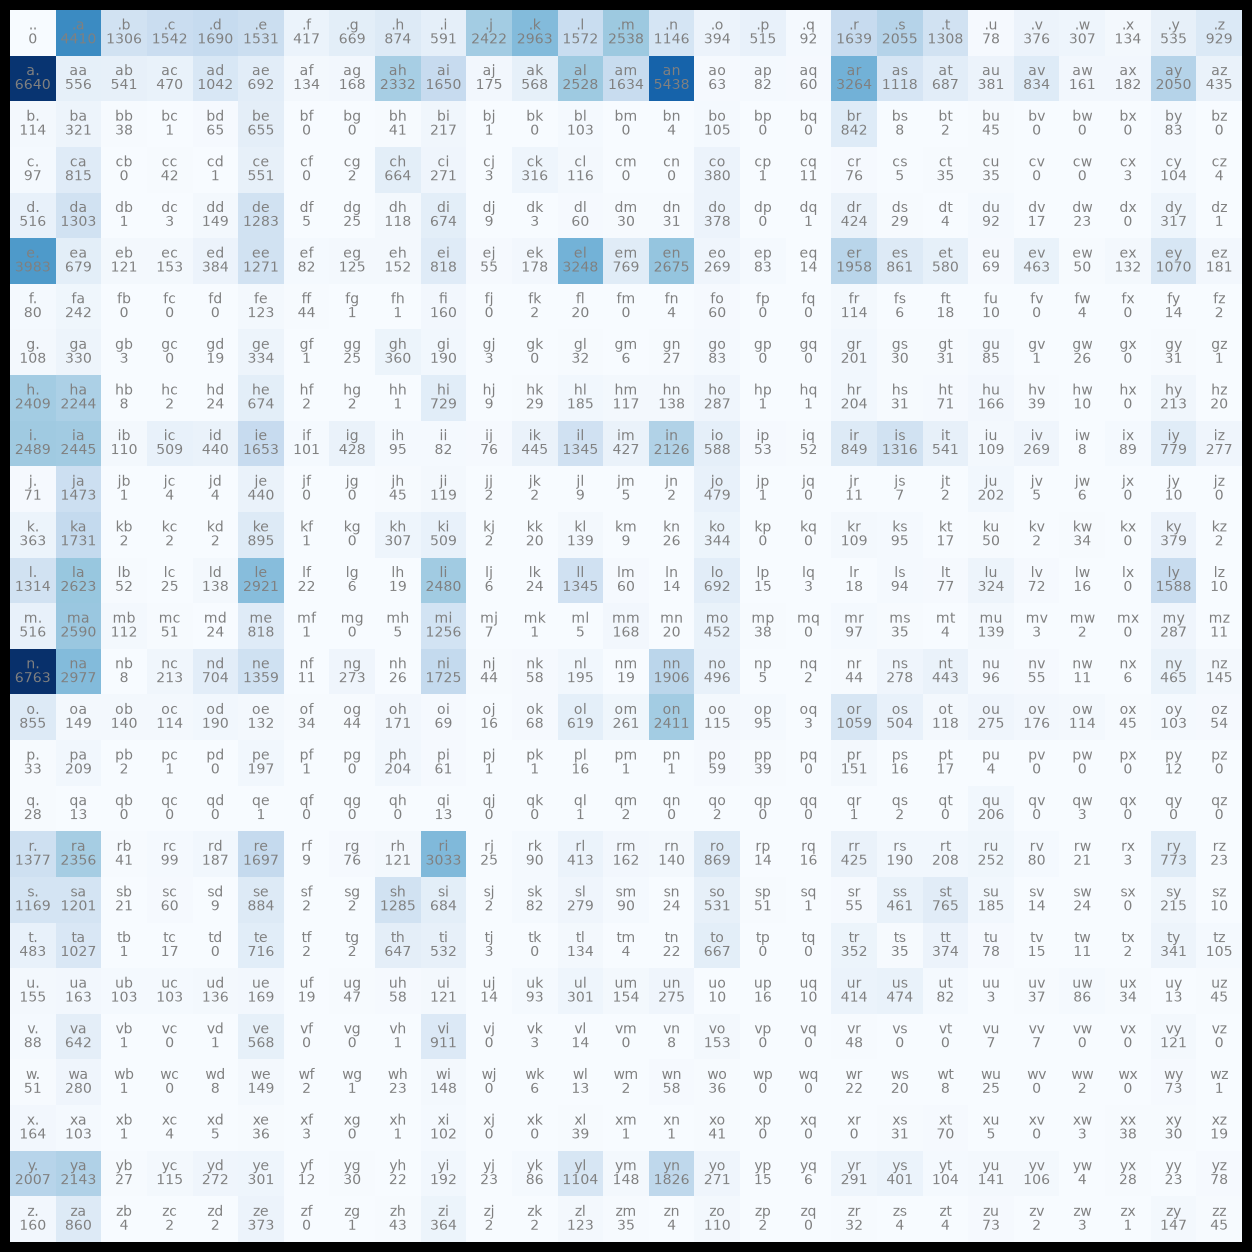

In [77]:
import  matplotlib.pyplot as plt
%matplotlib inline
plt.figure(figsize=(16,16))
plt.imshow(N,cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr=itos[i]+itos[j]
        plt.text(j,i,chstr,ha='center',va='bottom',color='gray')
        plt.text(j,i,N[i,j].item(),ha='center',va='top',color='gray')
plt.axis('off')

In [94]:
N[0,:]
p=N[0].float()
p=p/p.sum()
p

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [97]:
g=torch.Generator().manual_seed(2147483647)
ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
itos[ix]

'c'

In [88]:
g=torch.Generator().manual_seed(2147483647)
p=torch.rand(3,generator=g)
p=p/p.sum()
p

tensor([0.6064, 0.3033, 0.0903])

In [90]:
torch.multinomial(p,num_samples=100,replacement=True,generator=g)

tensor([0, 2, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 1, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0,
        2, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
        1, 0, 2, 0])

In [101]:
p.shape

torch.Size([27])

In [106]:
P=N.float()
#模型平滑。P=(N+1).float()

#P=P/P.sum()
p

tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [107]:
P.shape

torch.Size([27, 27])

In [110]:
P.sum(0,keepdim=True).shape #行
P.sum(1,keepdim=True)#列

tensor([[32033.],
        [33885.],
        [ 2645.],
        [ 3532.],
        [ 5496.],
        [20423.],
        [  905.],
        [ 1927.],
        [ 7616.],
        [17701.],
        [ 2900.],
        [ 5040.],
        [13958.],
        [ 6642.],
        [18327.],
        [ 7934.],
        [ 1026.],
        [  272.],
        [12700.],
        [ 8106.],
        [ 5570.],
        [ 3135.],
        [ 2573.],
        [  929.],
        [  697.],
        [ 9776.],
        [ 2398.]])

In [111]:
P=P/P.sum(1,keepdim=True) #广播定义

In [113]:
g=torch.Generator().manual_seed(2147483647)
for i in range(27):
    out=[]
    ix=0
    while True:
        #p=N[ix].float()
        #p=p/p.sum()
        #p=torch.ones(27)
        p=P[ix]
        ix=torch.multinomial(p,num_samples=1,replacement=True,generator=g).item()
        out.append(itos[ix])
        if ix==0:
            break
    print(''.join(out))

cexze.
momasurailezitynn.
konimittain.
llayn.
ka.
da.
staiyaubrtthrigotai.
moliellavo.
ke.
teda.
ka.
emimmsade.
enkaviyny.
ftlspihinivenvorhlasu.
dsor.
br.
jol.
pen.
aisan.
ja.
feniee.
zem.
deru.
firit.
gaikajahahbevare.
kiysthelenaririenah.
keen.


In [120]:
log_likelihood=0.0
n=0
for w in words:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        prob=P[ix1,ix2]
        logprob=torch.log(prob)
        log_likelihood+=logprob
        n+=1
        #print(f'{ch1},{ch2}:{prob:.4f} {logprob:.4f}')
print(f'{log_likelihood=}')
nll=-log_likelihood
print(f'{nll=}')
print(f'{nll/n}')


log_likelihood=tensor(-559891.7500)
nll=tensor(559891.7500)
2.454094171524048


In [140]:
xs,ys=[],[]
for w in words[:1]:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs=torch.tensor(xs)
ys=torch.tensor(ys)


In [150]:
xs.float()

tensor([ 0.,  5., 13., 13.,  1.])

In [151]:
ys.float()

tensor([ 5., 13., 13.,  1.,  0.])

In [157]:
import torch.nn.functional as F
xenc=F.one_hot(xs,num_classes=27).float()

In [158]:
xenc.shape

torch.Size([5, 27])

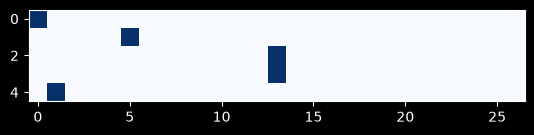

In [159]:
plt.imshow(xenc,cmap='Blues')


In [160]:
xenc.dtype

torch.float32

In [163]:
w=torch.randn((27,27))
xenc @ w

tensor([[-0.2208,  0.5043, -0.7806,  2.2492, -0.3706, -1.0812,  0.5405,  0.7672,
          0.5420, -0.9727, -0.7865,  0.5751, -1.7079,  1.1860, -1.0754, -0.9537,
          1.6496,  0.1902, -1.2227,  1.7352, -1.3608,  0.3568, -0.8962,  0.1445,
          2.0419, -1.0175, -0.4970],
        [-0.3968,  1.0293, -0.0749, -0.6573, -2.6845,  0.0625,  0.7667, -0.9528,
         -1.2860,  1.7094,  0.2918, -0.2537,  0.2274, -0.3661,  0.3567,  0.4219,
         -0.3117, -1.0328,  0.6375, -1.0252,  0.6441, -1.0107,  1.4939, -1.0262,
          1.0774, -0.1326, -0.7083],
        [-0.9539,  1.3654,  1.4632,  0.7694,  1.4751,  1.6025, -0.3690, -1.2026,
          0.3375,  0.0217,  0.8381,  1.6001, -0.4912, -0.2986,  0.2487, -0.0624,
         -0.3189, -0.3069,  1.2104, -0.8695,  0.1433, -1.3612,  0.9331,  0.4225,
         -0.7564,  0.9547, -0.2181],
        [-0.9539,  1.3654,  1.4632,  0.7694,  1.4751,  1.6025, -0.3690, -1.2026,
          0.3375,  0.0217,  0.8381,  1.6001, -0.4912, -0.2986,  0.2487, -0.0624

In [164]:
(xenc @ w).shape

torch.Size([5, 27])

In [165]:
(xenc @ w)[3,13]

tensor(-0.2986)

In [166]:
xenc[3]

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [168]:
w[:,13]

tensor([ 1.1860, -0.4287,  1.4981,  1.5771,  0.6017, -0.3661, -0.5129,  0.0104,
         0.6062, -1.0013, -1.3698, -1.3702,  0.4610, -0.2986,  1.9876,  1.7594,
         0.1209, -0.7734, -0.5092,  1.0149, -0.8231, -0.9249, -0.0165, -0.8376,
         1.5214,  1.0670, -0.3646])

In [169]:
(xenc @ w).exp()

tensor([[0.8019, 1.6558, 0.4581, 9.4806, 0.6903, 0.3392, 1.7168, 2.1536, 1.7195,
         0.3781, 0.4555, 1.7773, 0.1812, 3.2740, 0.3412, 0.3853, 5.2049, 1.2095,
         0.2944, 5.6700, 0.2565, 1.4288, 0.4081, 1.1555, 7.7052, 0.3615, 0.6083],
        [0.6724, 2.7991, 0.9279, 0.5183, 0.0683, 1.0645, 2.1527, 0.3857, 0.2764,
         5.5254, 1.3389, 0.7759, 1.2553, 0.6935, 1.4286, 1.5248, 0.7322, 0.3560,
         1.8918, 0.3587, 1.9042, 0.3640, 4.4545, 0.3584, 2.9372, 0.8758, 0.4925],
        [0.3852, 3.9171, 4.3200, 2.1584, 4.3715, 4.9652, 0.6914, 0.3004, 1.4015,
         1.0219, 2.3119, 4.9537, 0.6119, 0.7419, 1.2823, 0.9395, 0.7270, 0.7357,
         3.3547, 0.4192, 1.1541, 0.2564, 2.5425, 1.5257, 0.4693, 2.5979, 0.8041],
        [0.3852, 3.9171, 4.3200, 2.1584, 4.3715, 4.9652, 0.6914, 0.3004, 1.4015,
         1.0219, 2.3119, 4.9537, 0.6119, 0.7419, 1.2823, 0.9395, 0.7270, 0.7357,
         3.3547, 0.4192, 1.1541, 0.2564, 2.5425, 1.5257, 0.4693, 2.5979, 0.8041],
        [0.7029, 0.8966,

In [170]:
logits=xenc@w
counts=logits.exp()
probs=counts/counts.sum(1,keepdim=True)
probs

tensor([[0.0160, 0.0330, 0.0091, 0.1892, 0.0138, 0.0068, 0.0343, 0.0430, 0.0343,
         0.0075, 0.0091, 0.0355, 0.0036, 0.0653, 0.0068, 0.0077, 0.1039, 0.0241,
         0.0059, 0.1131, 0.0051, 0.0285, 0.0081, 0.0231, 0.1538, 0.0072, 0.0121],
        [0.0186, 0.0775, 0.0257, 0.0143, 0.0019, 0.0295, 0.0596, 0.0107, 0.0076,
         0.1529, 0.0371, 0.0215, 0.0347, 0.0192, 0.0395, 0.0422, 0.0203, 0.0099,
         0.0524, 0.0099, 0.0527, 0.0101, 0.1233, 0.0099, 0.0813, 0.0242, 0.0136],
        [0.0079, 0.0800, 0.0882, 0.0441, 0.0893, 0.1014, 0.0141, 0.0061, 0.0286,
         0.0209, 0.0472, 0.1012, 0.0125, 0.0152, 0.0262, 0.0192, 0.0148, 0.0150,
         0.0685, 0.0086, 0.0236, 0.0052, 0.0519, 0.0312, 0.0096, 0.0531, 0.0164],
        [0.0079, 0.0800, 0.0882, 0.0441, 0.0893, 0.1014, 0.0141, 0.0061, 0.0286,
         0.0209, 0.0472, 0.1012, 0.0125, 0.0152, 0.0262, 0.0192, 0.0148, 0.0150,
         0.0685, 0.0086, 0.0236, 0.0052, 0.0519, 0.0312, 0.0096, 0.0531, 0.0164],
        [0.0231, 0.0295,

In [176]:
probs[0].sum()

tensor(1.0000)

In [182]:
nlls=torch.zeros(5)
for i in range(5):
    x=xs[i].item()
    y=ys[i].item()
    print(f'{itos[x],{itos[y]}}')
    print("output",probs[i])
    p=probs[i,y]
    print(p.item())
    logp=torch.log(p)
    print(logp.item())
    nll=-logp
    print('negative',nll.item())
    nlls[i]=nll
    print(nlls.mean().item())

('.', {'e'})
output tensor([0.0160, 0.0330, 0.0091, 0.1892, 0.0138, 0.0068, 0.0343, 0.0430, 0.0343,
        0.0075, 0.0091, 0.0355, 0.0036, 0.0653, 0.0068, 0.0077, 0.1039, 0.0241,
        0.0059, 0.1131, 0.0051, 0.0285, 0.0081, 0.0231, 0.1538, 0.0072, 0.0121])
0.006768587976694107
-4.995462894439697
negative 4.995462894439697
0.9990925788879395
('e', {'m'})
output tensor([0.0186, 0.0775, 0.0257, 0.0143, 0.0019, 0.0295, 0.0596, 0.0107, 0.0076,
        0.1529, 0.0371, 0.0215, 0.0347, 0.0192, 0.0395, 0.0422, 0.0203, 0.0099,
        0.0524, 0.0099, 0.0527, 0.0101, 0.1233, 0.0099, 0.0813, 0.0242, 0.0136])
0.019191980361938477
-3.9532628059387207
negative 3.9532628059387207
1.7897450923919678
('m', {'m'})
output tensor([0.0079, 0.0800, 0.0882, 0.0441, 0.0893, 0.1014, 0.0141, 0.0061, 0.0286,
        0.0209, 0.0472, 0.1012, 0.0125, 0.0152, 0.0262, 0.0192, 0.0148, 0.0150,
        0.0685, 0.0086, 0.0236, 0.0052, 0.0519, 0.0312, 0.0096, 0.0531, 0.0164])
0.015152485109865665
-4.189590930938721
neg

In [205]:
g=torch.Generator().manual_seed(2147483647)
W=torch.randn((27,27),generator=g,requires_grad=True)
xenc=F.one_hot(xs,num_classes=27).float()
logits=xenc@W
counts=logits.exp()
probs=counts/counts.sum(1,keepdim=True)
probs

tensor([[0.0607, 0.0100, 0.0123, 0.0042, 0.0168, 0.0123, 0.0027, 0.0232, 0.0137,
         0.0313, 0.0079, 0.0278, 0.0091, 0.0082, 0.0500, 0.2378, 0.0603, 0.0025,
         0.0249, 0.0055, 0.0339, 0.0109, 0.0029, 0.0198, 0.0118, 0.1537, 0.1459],
        [0.0290, 0.0796, 0.0248, 0.0521, 0.1989, 0.0289, 0.0094, 0.0335, 0.0097,
         0.0301, 0.0702, 0.0228, 0.0115, 0.0181, 0.0108, 0.0315, 0.0291, 0.0045,
         0.0916, 0.0215, 0.0486, 0.0300, 0.0501, 0.0027, 0.0118, 0.0022, 0.0472],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0312, 0.0737, 0.0484, 0.0333, 0.0674, 0.0200, 0.0263, 0.0249, 0.1226,
         0.0164, 0.0075, 0.0789, 0.0131, 0.0267, 0.0147, 0.0112, 0.0585, 0.0121,
         0.0650, 0.0058, 0.0208, 0.0078, 0.0133, 0.0203, 0.1204, 0.0469, 0.0126],
        [0.0150, 0.0086,

In [206]:
probs.shape

torch.Size([5, 27])

In [207]:
#probs[0,5],probs[1,13],probs[2,13],probs[3,1],probs[4,0]

In [208]:
loss=-probs[torch.arange(5),ys].log().mean()
loss

tensor(3.7693, grad_fn=<NegBackward0>)

In [211]:
print(loss.item())

3.7693049907684326


In [212]:
W.grad

In [216]:
#backward pass
W.grad=None
loss.backward()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.

In [215]:
W.data+=-0.1*W.grad

In [220]:
xs,ys=[],[]
for w in words[:1]:
    chs=['.']+list(w)+['.']
    for ch1,ch2 in zip(chs, chs[1:]):
        ix1=stoi[ch1]
        ix2=stoi[ch2]
        xs.append(ix1)
        ys.append(ix2)
xs=torch.tensor(xs)
ys=torch.tensor(ys)
num=xs.nelement()
print(num)

g=torch.Generator().manual_seed(2147483647)
W=torch.randn((27,27),generator=g,requires_grad=True)

5


In [224]:
for i in range(100):
    xenc=F.one_hot(xs,num_classes=27).float()
    logits=xenc@W
    counts=logits.exp()
    probs=counts/counts.sum(1,keepdim=True)
    loss=-probs[torch.arange(num),ys].log().mean()+0.01*(W**2).mean()
    print(loss.item())
    W.grad=None
    loss.backward()
    W.data+=-50*W.grad


2.3067691326141357
1.7308623790740967
2.3044326305389404
1.733047366142273
2.302119493484497
1.7352092266082764
2.2998299598693848
1.7373485565185547
2.2975640296936035
1.7394661903381348
2.295320987701416
1.7415615320205688
2.293100595474243
1.7436370849609375
2.290900707244873
1.7456910610198975
2.2887234687805176
1.7477245330810547
2.2865676879882812
1.7497379779815674
2.284433126449585
1.7517316341400146
2.282318115234375
1.7537063360214233
2.280224084854126
1.7556604146957397
2.2781505584716797
1.7575968503952026
2.2760956287384033
1.7595149278640747
2.274059295654297
1.761414647102356
2.2720425128936768
1.7632970809936523
2.2700443267822266
1.7651622295379639
2.268063545227051
1.7670098543167114
2.2661004066467285
1.768841028213501
2.264155626296997
1.7706561088562012
2.262227773666382
1.7724535465240479
2.2603180408477783
1.7742353677749634
2.2584245204925537
1.7760015726089478
2.25654673576355
1.7777520418167114
2.2546863555908203
1.7794874906539917
2.2528421878814697
1.7812073